In [59]:
import arviz as az
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from risk_experiment.symbolic_experiment.fit_nlc import build_model, get_data
from risk_experiment.cogmodels.utils import plot_ppc

import numpy as np

from pathlib import Path

sns.set_context('talk')

bids_folder = Path('/data/ds-symbolicrisk')
figure_folder = bids_folder / 'derivatives' / 'figures'
figure_folder.mkdir(parents=True, exist_ok=True)

In [2]:
def get_hdi(d):
    return az.hdi(d.values)

def plot_hdi(data, x, y):
    hdi = data.groupby(y)[x].apply(get_hdi)
    return hdi

# Get all PPCs

In [ ]:
df = get_data(None)

idatas = {}
ppcs = []

model_labels = [-1, 0, 1, 2, 5]

for model_label in model_labels:
    idata = az.from_netcdf(f'/data/ds-symbolicrisk/derivatives/risk_model/nlc/model{model_label}_samples.nc')
    model = build_model(model_label)

    ppc = model.ppc(idata=idata.sel(draw=slice(None, None, 10)), paradigm=df)
    ppc = ppc.stack([0, 1])
    ppc = ppc.where(~ppc.index.get_level_values('risky_first'), 1-ppc).astype(bool).to_frame('predicted_choice')

    ppcs.append(ppc)
    idatas[model_label] = idata

ppc = pd.concat(ppcs, keys=model_labels, names=['model'])

Sampling: [ll_bernoulli]


Output()

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_68036/2409166742.py:13: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ppc = ppc.stack([0, 1])
Sampling: [ll_bernoulli]


Output()

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_68036/2409166742.py:13: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ppc = ppc.stack([0, 1])
Sampling: [ll_bernoulli]


...

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_68036/2409166742.py:13: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ppc = ppc.stack([0, 1])
Sampling: [ll_bernoulli]


Output()

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_68036/2409166742.py:13: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ppc = ppc.stack([0, 1])
Sampling: [ll_bernoulli]


Output()

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_68036/2409166742.py:13: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ppc = ppc.stack([0, 1])
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_68036/2409166742.py:19: FutureWarning: The behavior of pd.concat with len(keys) != len(objs) is deprecated. In a future version this will raise instead of truncating to the smaller of the two sequences
  ppc = pd.concat(ppcs, keys=[-1, 0], names=['model'])


In [8]:
keys = ['n_safe_bin', 'Order',]

group_ppc = ppc.groupby(['model', 'subject'] + keys + ['chain', 'draw']).mean().groupby(['model'] + keys + ['chain', 'draw']).mean()
group_choice = df.groupby(keys)['chose_risky'].mean()
group_stats = group_ppc.join(group_choice)

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_68036/448141551.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_ppc = ppc.groupby(['model', 'subject'] + keys + ['chain', 'draw']).mean().groupby(['model'] + keys + ['chain', 'draw']).mean()
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_68036/448141551.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_ppc = ppc.groupby(['model', 'subject'] + keys + ['chain', 'draw']).mean().groupby(['model'] + keys + ['chain', 'draw']).mean()
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_68036/448141551.py:4: FutureWarning: 

In [9]:
group_stats

predicted_choice  chose_risky
model n_safe_bin Order       chain draw                               
-1    5-7        Risky first 0     0             0.478531     0.461946
                                   10            0.483084     0.461946
                                   20            0.487122     0.461946
                                   30            0.472521     0.461946
                                   40            0.474908     0.461946
...                                                   ...          ...
 5    19-28      Safe first  3     2950          0.490538     0.498654
                                   2960          0.483704     0.498654
                                   2970          0.469820     0.498654
                                   2980          0.486747     0.498654
                                   2990          0.473480     0.498654

[60000 rows x 2 columns]

In [11]:
model_label_map = {-1: 'Different priors, equal noise', 0: 'Equal priors, equal noise', 1: 'Equal priors, different noise',
                   2: 'Different priors, different noise', 5: 'Expected utility model'}

In [13]:
group_stats['model_label'] = group_stats.index.get_level_values('model').map(model_label_map)

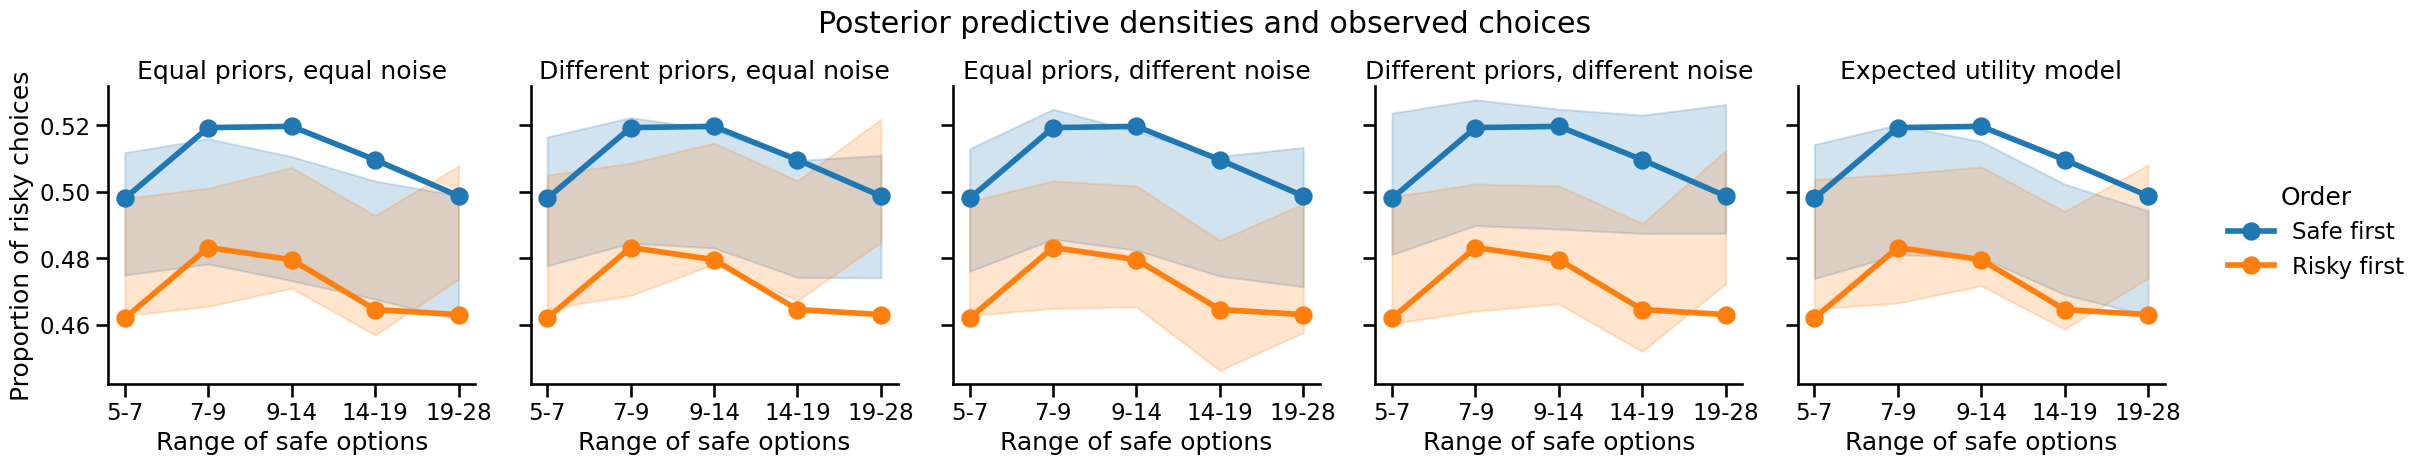

In [110]:


g = sns.FacetGrid(data=group_stats.reset_index(), hue='Order', col='model_label', hue_order=['Safe first', 'Risky first'],
                  col_order=['Equal priors, equal noise', 'Different priors, equal noise',
                             'Equal priors, different noise', 'Different priors, different noise',
                             'Expected utility model'], height=4.5)

g.set_titles('{col_name}')

g.map_dataframe(sns.pointplot, x='n_safe_bin', y='chose_risky')

g.add_legend()
g.map_dataframe(sns.lineplot, x='n_safe_bin', y='predicted_choice', errorbar=get_hdi,
                linewidth=0)

g.set_axis_labels('Range of safe options', 'Proportion of risky choices')

g.fig.suptitle('Posterior predictive densities and observed choices', y=1.05)

g.savefig(figure_folder / 'ppc_nlc.pdf', bbox_inches='tight')

In [151]:
group_stats['mean_predicted_choice'] = group_stats['predicted_choice'].groupby(level=['model', 'n_safe_bin', 'Order']).mean()

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_68036/4191358780.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats['mean_predicted_choice'] = group_stats['predicted_choice'].groupby(level=['model', 'n_safe_bin', 'Order']).mean()


In [152]:
group_stats

predicted_choice  chose_risky  \
model n_safe_bin Order       chain draw                                  
-1    5-7        Risky first 0     0             0.478531     0.461946   
                                   10            0.483084     0.461946   
                                   20            0.487122     0.461946   
                                   30            0.472521     0.461946   
                                   40            0.474908     0.461946   
...                                                   ...          ...   
 5    19-28      Safe first  3     2950          0.490538     0.498654   
                                   2960          0.483704     0.498654   
                                   2970          0.469820     0.498654   
                                   2980          0.486747     0.498654   
                                   2990          0.473480     0.498654   

                                                           model_label  \
model n_safe_bin Order       chain draw                                  
-1    5-7        Risky first 0     0     Different priors, equal noise   
                                   10    Different priors, equal noise   
                                   20    Different priors, equal noise   
                                   30    Different priors, equal noise   
                                   40    Different priors, equal noise   
...                                                                ...   
 5    19-28      Safe first  3     2950         Expected utility model   
                                   2960         Expected utility model   
                                   2970         Expected utility model   
                                   2980         Expected utility model   
                                   2990         Expected utility model   

                                         mean_predicted_choice  
model n_safe_bin Order       chain draw                         
-1    5-7        Risky first 0     0                  0.483772  
                                   10                 0.483772  
                                   20                 0.483772  
                                   30                 0.483772  
                                   40                 0.483772  
...                                                        ...  
 5    19-28      Safe first  3     2950               0.478675  
                                   2960               0.478675  
                                   2970               0.478675  
                                   2980               0.478675  
                                   2990               0.478675  

[60000 rows x 4 columns]

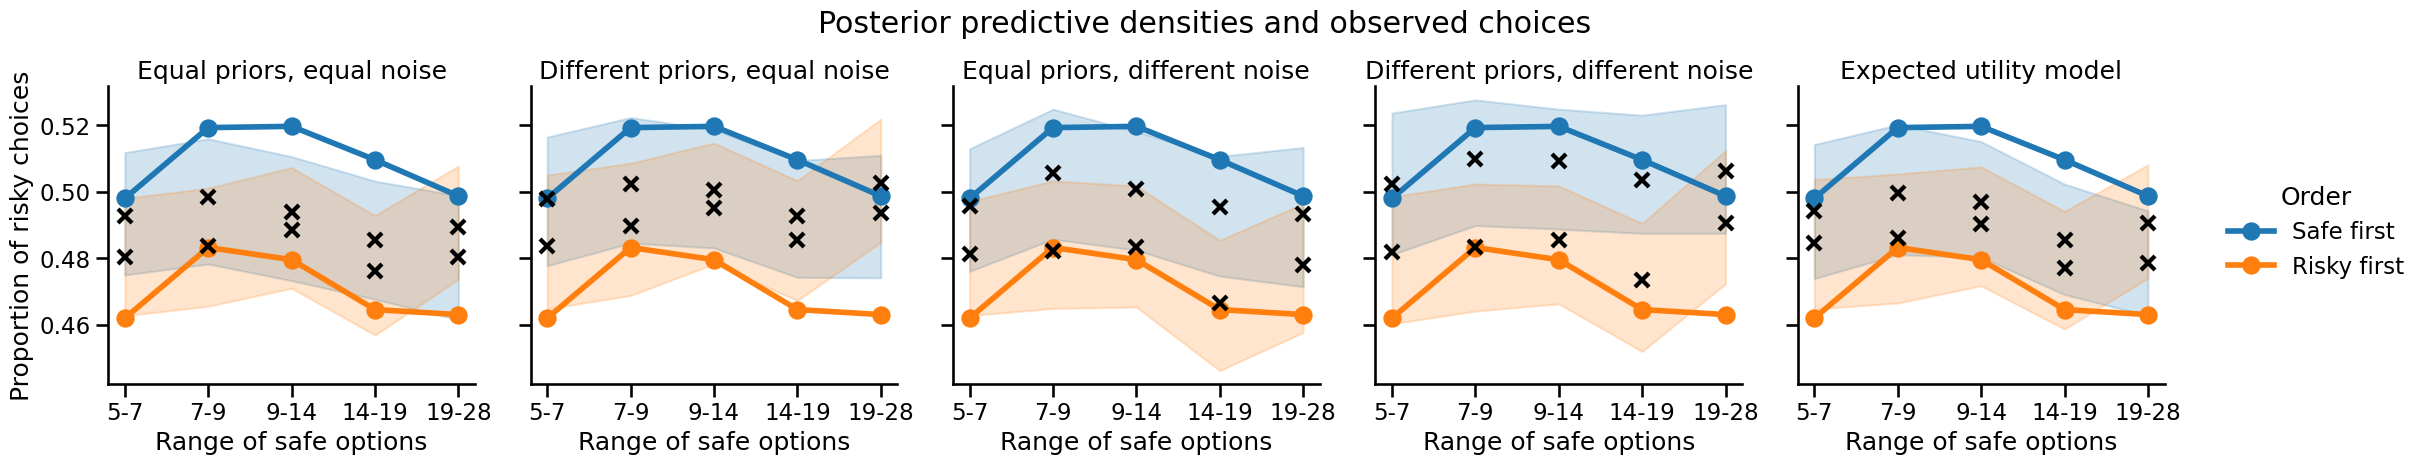

In [190]:


g = sns.FacetGrid(data=group_stats.reset_index(), hue='Order', col='model_label', hue_order=['Safe first', 'Risky first'],
                  col_order=['Equal priors, equal noise', 'Different priors, equal noise',
                             'Equal priors, different noise', 'Different priors, different noise',
                             'Expected utility model'], height=4.5)

g.set_titles('{col_name}')

g.map_dataframe(sns.pointplot, x='n_safe_bin', y='chose_risky')
g.add_legend()
g.map_dataframe(sns.pointplot, x='n_safe_bin', y='mean_predicted_choice', markers='x',  linestyle='none', color='black')

g.map_dataframe(sns.lineplot, x='n_safe_bin', y='predicted_choice', errorbar=get_hdi,
                linewidth=0)

g.set_axis_labels('Range of safe options', 'Proportion of risky choices')

g.fig.suptitle('Posterior predictive densities and observed choices', y=1.05)

g.savefig(figure_folder / 'ppc_nlc.pdf', bbox_inches='tight')

# Model 2

2.4732263188233423

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_68036/2882571897.py:36: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.kdeplot(data=pars.xs('Evidence SD', level='group').reset_index(), hue='parameter', x='value', ax=axes[0], fill=True, common_norm=False, palette=palette, legend=False, hue_order=['n1_evidence_sd_mu', 'n2_evidence_sd_mu'])


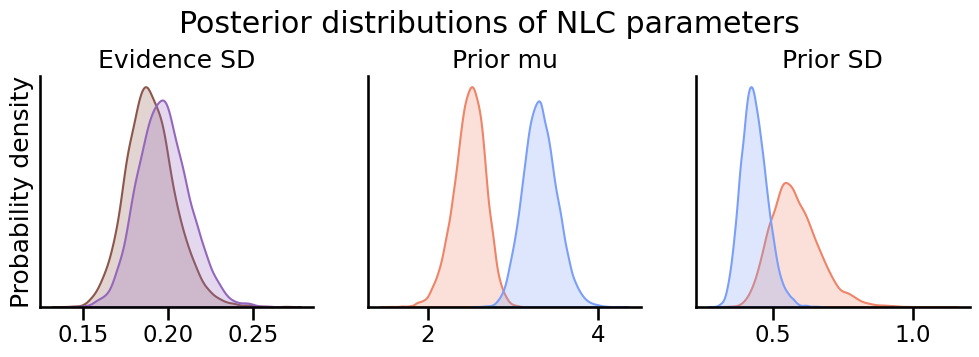

In [236]:
model_label = 2
idata = idatas[model_label]


pars = idata.posterior[['risky_prior_mu_mu', 'safe_prior_mu_mu', 'risky_prior_sd_mu', 'safe_prior_sd_mu',
                 'n1_evidence_sd_mu', 'n2_evidence_sd_mu']].to_dataframe()

pars.columns.name = 'parameter'


pars = pars.stack().to_frame('value')

pars['group'] = pars.index.get_level_values('parameter').map({'risky_prior_mu_mu': 'Prior mean',
                                              'safe_prior_mu_mu': 'Prior mean',
                                              'risky_prior_sd_mu': 'Prior SD',
                                              'safe_prior_sd_mu': 'Prior SD',
                                              'n1_evidence_sd_mu': 'Evidence SD',
                                              'n2_evidence_sd_mu': 'Evidence SD'})

pars.set_index('group', append=True, inplace=True)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

palette = sns.color_palette('coolwarm', 4)
palette = [palette[ix] for ix in [0, 3]]

sns.kdeplot(data=pars.xs('Prior mean', level='group').reset_index(), hue='parameter', x='value', ax=axes[1], fill=True, common_norm=False, palette=palette, legend=False, hue_order=['safe_prior_mu_mu', 'risky_prior_mu_mu'])
axes[1].set_title('Prior mu')


sns.kdeplot(data=pars.xs('Prior SD', level='group').reset_index(), hue='parameter', x='value', ax=axes[2], fill=True, common_norm=False, palette=palette, legend=False, hue_order=['safe_prior_sd_mu', 'risky_prior_sd_mu'])
axes[2].set_title('Prior SD')


palette = sns.color_palette()[4:]
sns.kdeplot(data=pars.xs('Evidence SD', level='group').reset_index(), hue='parameter', x='value', ax=axes[0], fill=True, common_norm=False, palette=palette, legend=False, hue_order=['n1_evidence_sd_mu', 'n2_evidence_sd_mu'])
axes[0].set_title('Evidence SD')

for ax in axes:
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    ax.set_yticks([])

axes[0].set_ylabel('Probability density')   

sns.despine()

fig.suptitle('Posterior distributions of NLC parameters', y=1.1)
fig.savefig(figure_folder / 'nlc_parameters.pdf', bbox_inches='tight')

In [ ]:
model_label = 2
idata = idatas[model_label]


pars = idata.posterior[['risky_prior_mu_mu', 'safe_prior_mu_mu', 'risky_prior_sd_mu', 'safe_prior_sd_mu',
                 'n1_evidence_sd_mu', 'n2_evidence_sd_mu']].to_dataframe()

pars.columns.name = 'parameter'


pars = pars.stack().to_frame('value')

pars['group'] = pars.index.get_level_values('parameter').map({'risky_prior_mu_mu': 'Prior mean',
                                              'safe_prior_mu_mu': 'Prior mean',
                                              'risky_prior_sd_mu': 'Prior SD',
                                              'safe_prior_sd_mu': 'Prior SD',
                                              'n1_evidence_sd_mu': 'Evidence SD',
                                              'n2_evidence_sd_mu': 'Evidence SD'})

pars.set_index('group', append=True, inplace=True)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

palette = sns.color_palette('coolwarm', 4)
palette = [palette[ix] for ix in [0, 3]]

sns.kdeplot(data=pars.xs('Prior mean', level='group').reset_index(), hue='parameter', x='value', ax=axes[1], fill=True, common_norm=False, palette=palette, legend=False, hue_order=['safe_prior_mu_mu', 'risky_prior_mu_mu'])
axes[1].set_title('Prior mu')

axes[1].axvline(np.log(df['n_safe']).mean(), color=palette[0], linestyle='--', label='Mean log safe options')
axes[1].axvline(np.log(df['n_risky']).mean(), color=palette[1], linestyle='--', label='Mean log risky options')

sns.kdeplot(data=pars.xs('Prior SD', level='group').reset_index(), hue='parameter', x='value', ax=axes[2], fill=True, common_norm=False, palette=palette, legend=False, hue_order=['safe_prior_sd_mu', 'risky_prior_sd_mu'])
axes[2].set_title('Prior SD')

axes[2].axvline(np.log(df['n_safe']).std(), color=palette[0], linestyle='--', label='Mean log safe options')
axes[2].axvline(np.log(df['n_risky']).std(), color=palette[1], linestyle='--', label='Mean log risky options')

palette = sns.color_palette()[4:]
sns.kdeplot(data=pars.xs('Evidence SD', level='group').reset_index(), hue='parameter', x='value', ax=axes[0], fill=True, common_norm=False, palette=palette, legend=False, hue_order=['n1_evidence_sd_mu', 'n2_evidence_sd_mu'])
axes[0].set_title('Evidence SD')

for ax in axes:
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    ax.set_yticks([])

axes[0].set_ylabel('Probability density')   

sns.despine()

fig.suptitle('Posterior distributions of NLC parameters', y=1.1)
# fig.savefig(figure_folder / 'nlc_parameters.pdf', bbox_inches='tight')

In [213]:
evidence_sd

value
chain draw subject n                       
0     0    100     n1_evidence_sd  0.047879
                   n2_evidence_sd  0.095258
           101     n1_evidence_sd  0.162552
                   n2_evidence_sd  0.148610
           102     n1_evidence_sd  0.161302
...                                     ...
3     2999 97      n2_evidence_sd  0.163173
           98      n1_evidence_sd  0.098893
                   n2_evidence_sd  0.174207
           99      n1_evidence_sd  0.130374
                   n2_evidence_sd  0.194517

[1392000 rows x 1 columns]

In [216]:
evidence_sd

value
chain draw subject                         
0     0    100     n1_evidence_sd  0.047879
                   n2_evidence_sd  0.095258
           101     n1_evidence_sd  0.162552
                   n2_evidence_sd  0.148610
           102     n1_evidence_sd  0.161302
...                                     ...
3     2999 97      n2_evidence_sd  0.163173
           98      n1_evidence_sd  0.098893
                   n2_evidence_sd  0.174207
           99      n1_evidence_sd  0.130374
                   n2_evidence_sd  0.194517

[1392000 rows x 1 columns]

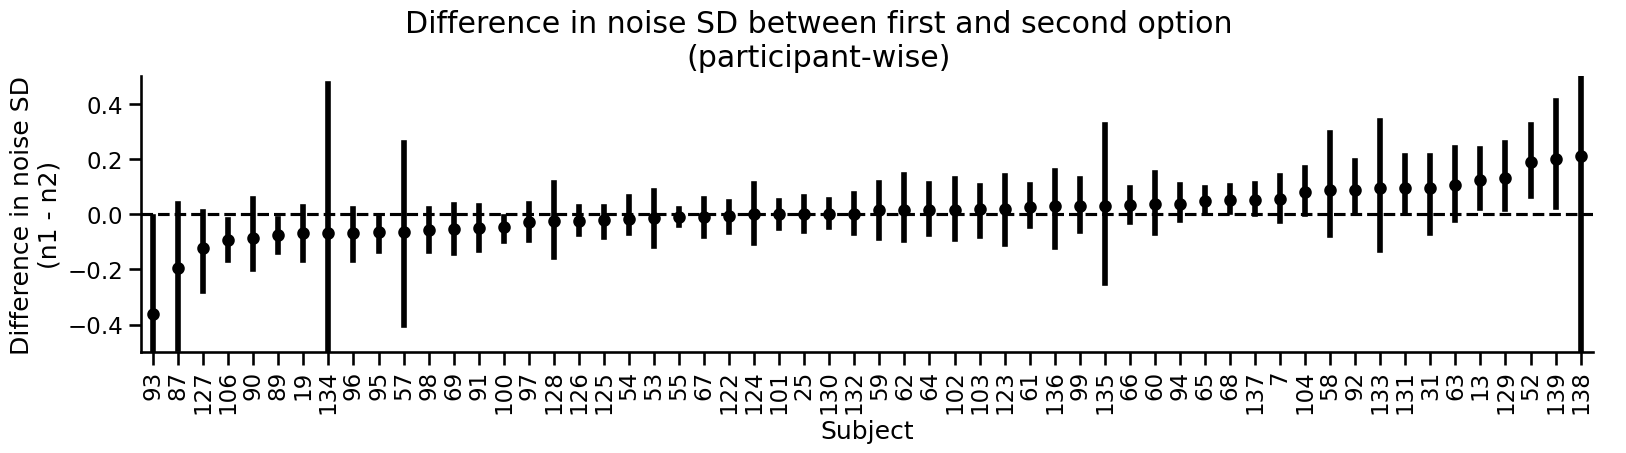

In [217]:
evidence_sd = idata.posterior[['n1_evidence_sd', 'n2_evidence_sd']].to_dataframe().stack().to_frame('value')

evidence_sd.index.set_names('n', level=-1, inplace=True)
tmp = evidence_sd.unstack('n').droplevel(0,1)

tmp['evidence_sd'] = np.sqrt(tmp['n1_evidence_sd']**2 + tmp['n2_evidence_sd']**2)

evidence_sd = tmp.stack().to_frame('value')
diff = evidence_sd.xs('n1_evidence_sd', level=-1)['value'] - evidence_sd.xs('n2_evidence_sd', level=-1)['value']

order = diff.groupby('subject').mean().sort_values(ascending=True).index


g = sns.catplot(y='difference', x='subject', data=diff.to_frame('difference'),
            errorbar=get_hdi, kind='point', order=order, color='k',
            linestyle='',
            aspect=4., height=4, markersize=6,
            )
plt.axhline(0.0, c='k', ls='--')


# g.set_xticks
# Rotate xticks 90 degrees
g.set_xticklabels(g.ax.get_xticklabels(), rotation=90)

g.set_xlabels('Subject')

g.set_ylabels('Difference in noise SD\n(n1 - n2)')

g.set(ylim=(-.5, .5))

g.fig.suptitle('Difference in noise SD between first and second option\n(participant-wise)', y=1.1)

g.savefig(figure_folder / 'nlc_noise_sd_individual.pdf', bbox_inches='tight')

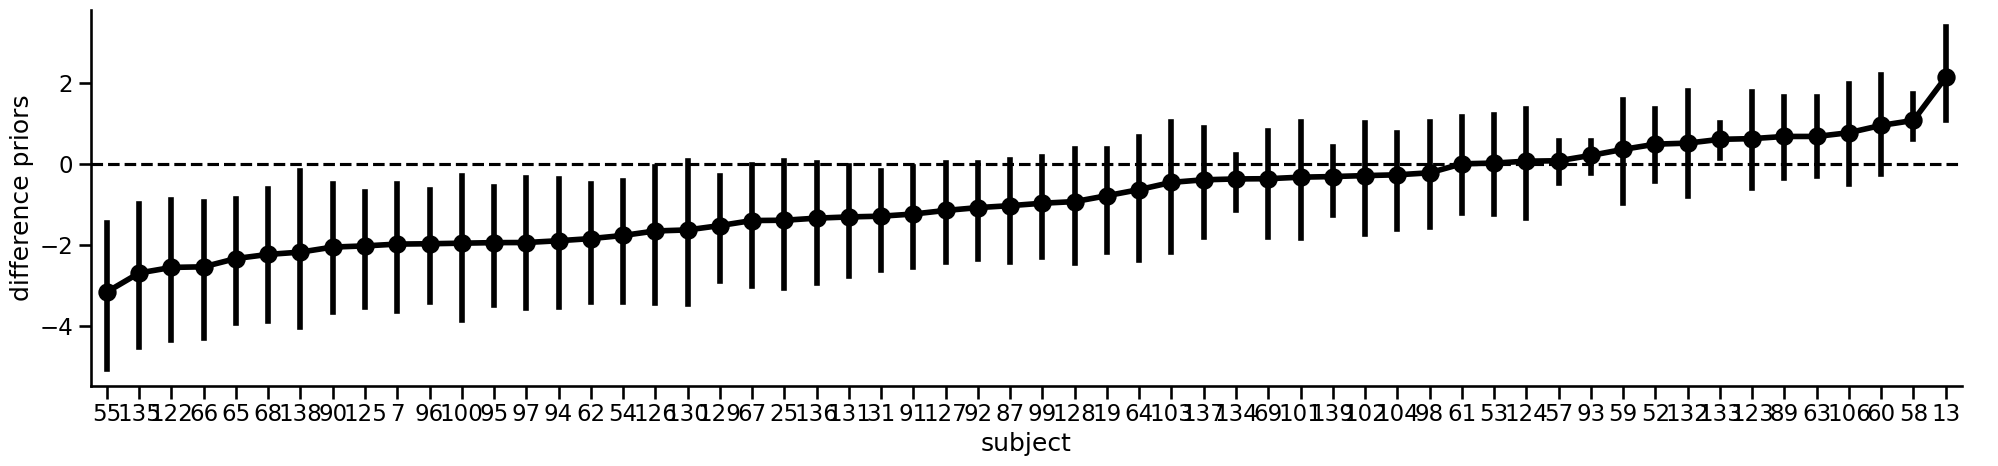

In [218]:
risky_prior_ind = idata.posterior[['risky_prior_mu', 'safe_prior_mu']].to_dataframe().stack().to_frame('value')

risky_prior_ind.index.set_names('parameter', level=-1, inplace=True)


prior_diff = risky_prior_ind.xs('risky_prior_mu', level=-1)['value'] - risky_prior_ind.xs('safe_prior_mu', level=-1)['value']
prior_diff.name = 'difference priors'
prior_diff = prior_diff.to_frame()

prior_diff_mean = prior_diff.groupby('subject').mean().sort_values(by='difference priors', ascending=True)
diff_hdi = prior_diff.groupby(['subject'])['difference priors'].apply(lambda x: pd.Series(get_hdi(x), index=['hdi_low', 'hdi_high'])).unstack()

sns.catplot(y='difference priors', x='subject', data=prior_diff,
            errorbar=get_hdi, kind='point', order=prior_diff_mean.index, color='k', aspect=4.)
plt.axhline(0.0, c='k', ls='--')

In [ ]:
evidence_sd


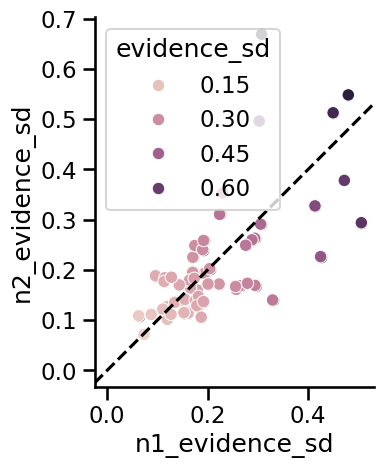

In [221]:
evidence_sd.index.set_names('n', level=-1, inplace=True)
sns.scatterplot(x='n1_evidence_sd', y='n2_evidence_sd', data=evidence_sd.unstack('n').droplevel(0,1).groupby(['subject']).mean(), color='k')
sns.scatterplot(x='n1_evidence_sd', y='n2_evidence_sd', data=evidence_sd.unstack('n').droplevel(0,1).groupby(['subject']).mean(), hue='evidence_sd')

plt.axline((0,0), slope=1, color='k', ls='--')

sns.despine()

# Make the plot square
plt.gca().set_aspect('equal', adjustable='box')

In [211]:
diff_hdi = diff.groupby('subject').apply(lambda x: pd.Series(get_hdi(x), index=['hdi_lower', 'hdi_higher'])).unstack()

print( (diff_hdi['hdi_lower'] > 0.0).sum(), (diff_hdi['hdi_higher'] < 0.0).sum())

diff_mean = diff.groupby('subject').mean()

(diff_mean > 0.0).sum(), (diff_mean > 0.0).mean()

10 5


(33, 0.5689655172413793)

In [212]:
evidence_sd

value
chain draw subject n                       
0     0    100     n1_evidence_sd  0.047879
                   n2_evidence_sd  0.095258
           101     n1_evidence_sd  0.162552
                   n2_evidence_sd  0.148610
           102     n1_evidence_sd  0.161302
...                                     ...
3     2999 97      n2_evidence_sd  0.163173
           98      n1_evidence_sd  0.098893
                   n2_evidence_sd  0.174207
           99      n1_evidence_sd  0.130374
                   n2_evidence_sd  0.194517

[1392000 rows x 1 columns]

In [202]:
evidence_sd

value
chain draw subject n                       
0     0    100     n1_evidence_sd  0.047879
                   n2_evidence_sd  0.095258
           101     n1_evidence_sd  0.162552
                   n2_evidence_sd  0.148610
           102     n1_evidence_sd  0.161302
...                                     ...
3     2999 97      n2_evidence_sd  0.163173
           98      n1_evidence_sd  0.098893
                   n2_evidence_sd  0.174207
           99      n1_evidence_sd  0.130374
                   n2_evidence_sd  0.194517

[1392000 rows x 1 columns]

In [194]:
diff_hdi

,hdi_lower,hdi_higher
subject,,
100,-0.095478,-0.010098
101,-0.049579,0.047696
102,-0.091454,0.128736
103,-0.078937,0.103747
104,0.001486,0.167585
106,-0.165393,-0.020446
122,-0.063067,0.044570
123,-0.106657,0.137209
124,-0.106226,0.107752


In [184]:
memory_noise1 = diff_hdi.index[(diff_hdi['hdi_lower'] > 0.0)]
len(memory_noise1)

10

In [185]:
memory_noise2 = diff_hdi.index[(diff_hdi['hdi_higher'] < 0.0)]
len(memory_noise2)

5

In [186]:
df.loc[memory_noise1, 'group'] = 'Memory noise 1'
df.loc[diff_hdi.index[(diff_hdi['hdi_higher'] < 0.0)], 'group'] = 'Memory noise 2'

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_68036/3756186899.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = df.groupby(['group', 'subject', 'n_safe_bin', 'Order'])['chose_risky'].mean()


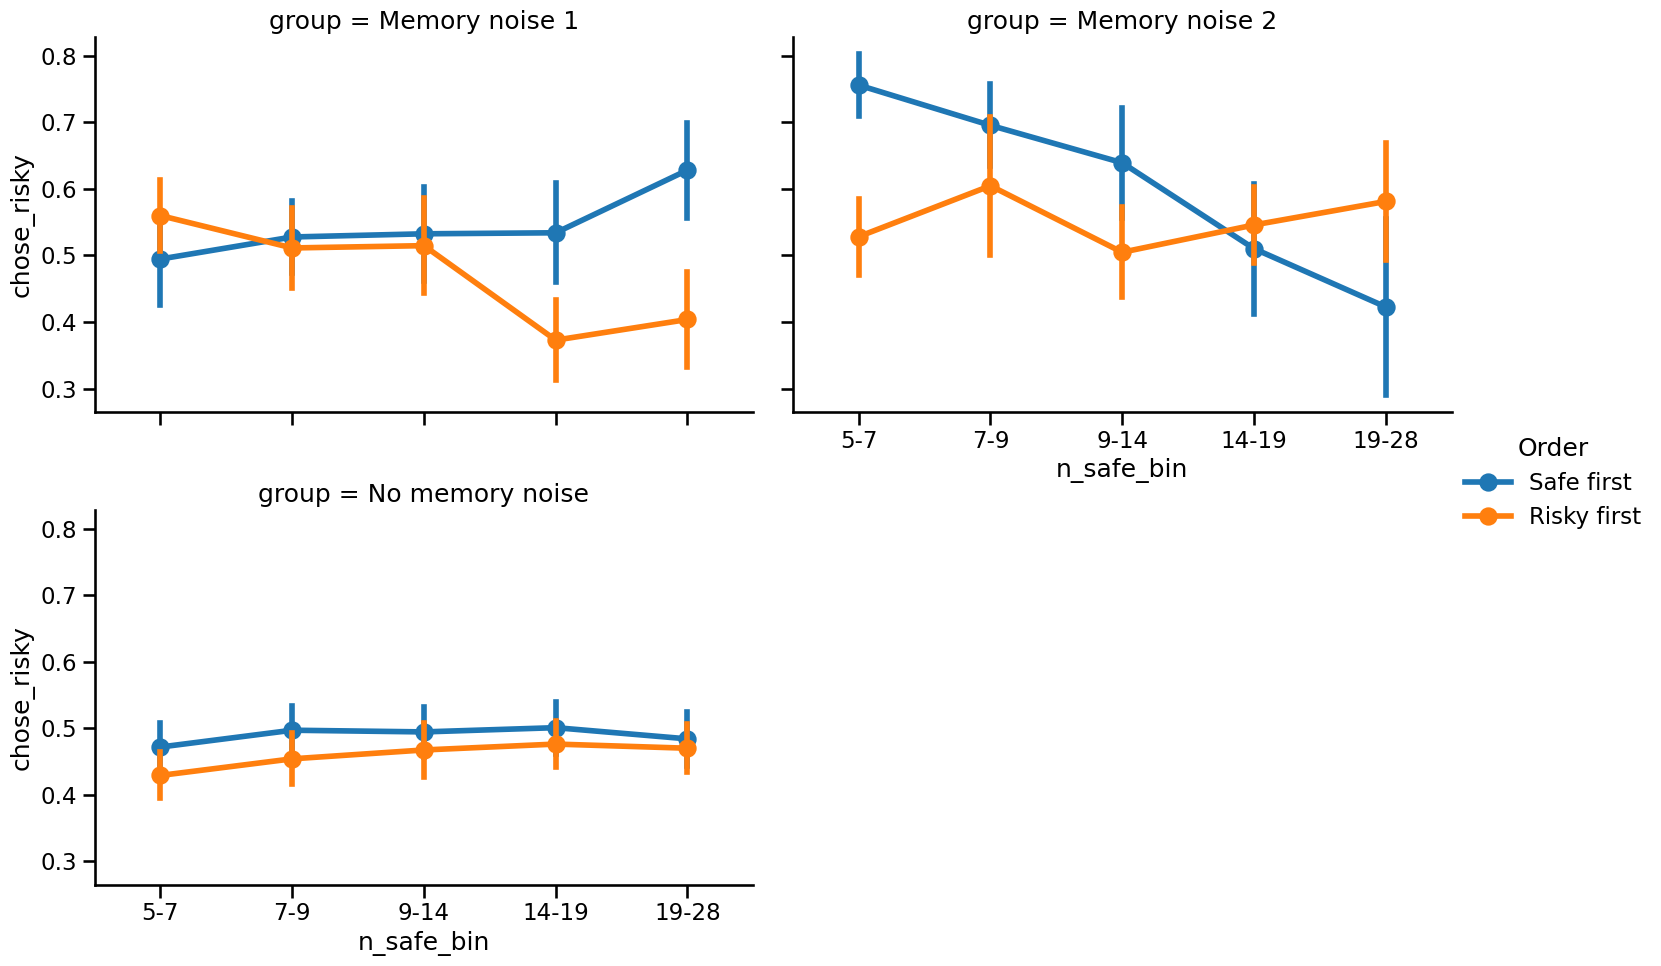

In [188]:
tmp = df.groupby(['group', 'subject', 'n_safe_bin', 'Order'])['chose_risky'].mean()

sns.catplot(y='chose_risky', x='n_safe_bin', data=tmp.reset_index(),
            errorbar='se', kind='point', col='group', col_wrap=2, aspect=1.5, hue='Order', hue_order=['Safe first', 'Risky first'],)

10 4


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_68036/3832460117.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = df.groupby(['group', 'subject', 'n_safe_bin', 'Order'])['chose_risky'].mean()


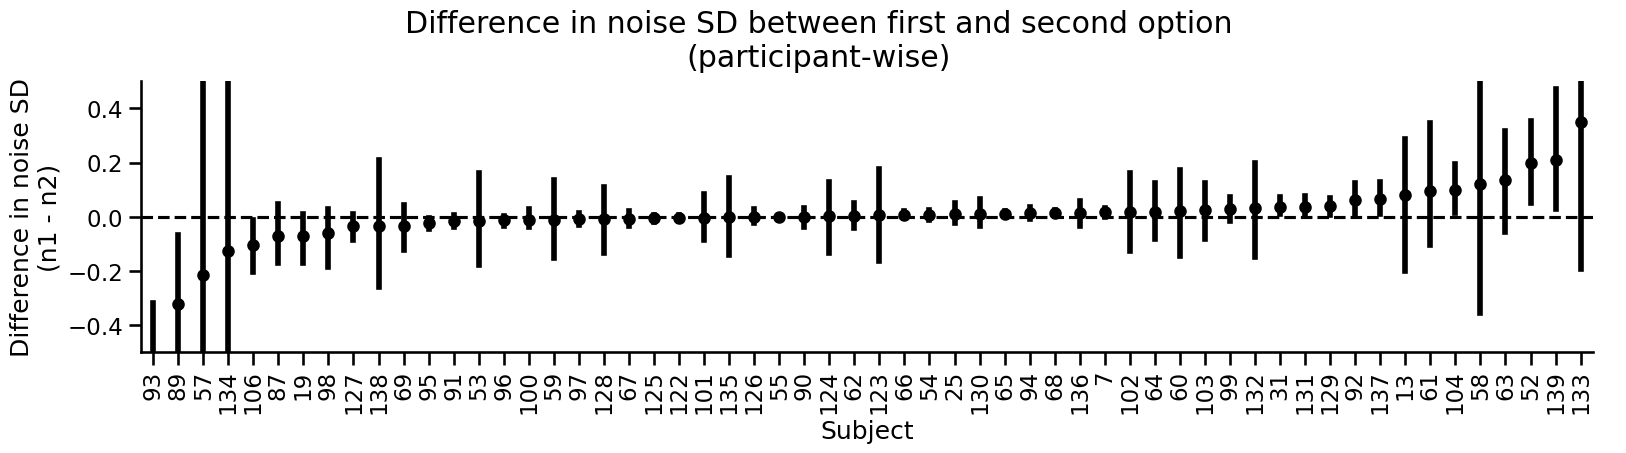

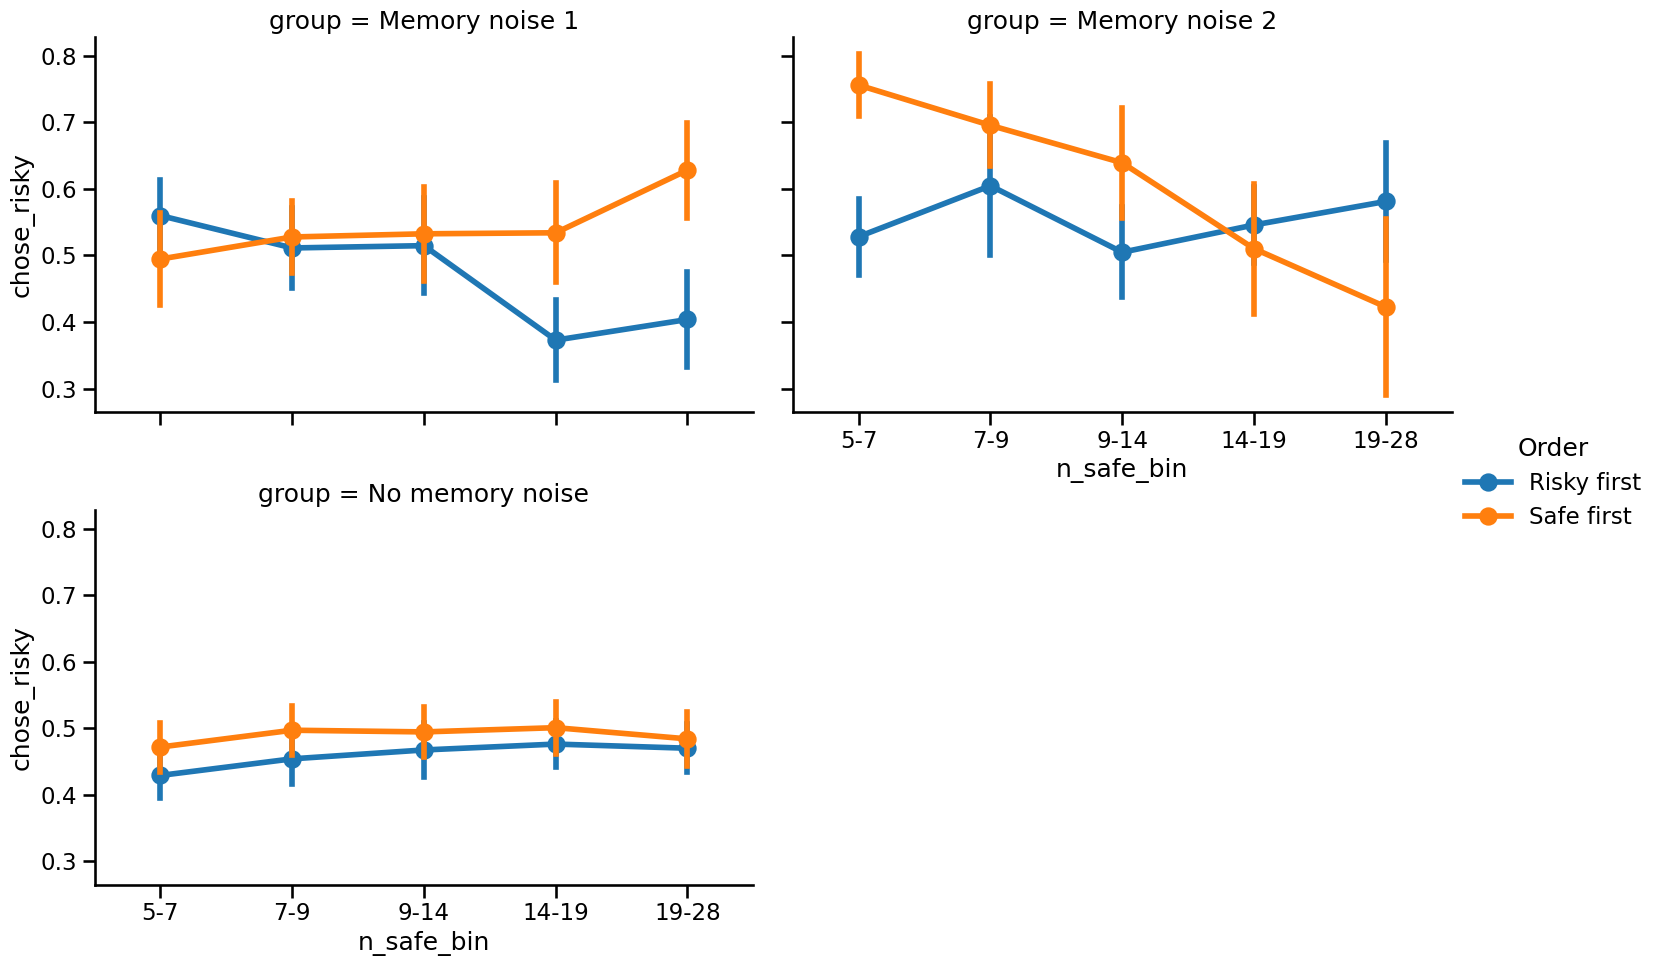

In [175]:
# Model 1:
idata = idatas[1]

evidence_sd = idata.posterior[['n1_evidence_sd', 'n2_evidence_sd']].to_dataframe().stack().to_frame('value')

diff = evidence_sd.xs('n1_evidence_sd', level=-1)['value'] - evidence_sd.xs('n2_evidence_sd', level=-1)['value']

order = diff.groupby('subject').mean().sort_values(ascending=True).index


g = sns.catplot(y='difference', x='subject', data=diff.to_frame('difference'),
            errorbar=get_hdi, kind='point', order=order, color='k',
            linestyle='',
            aspect=4., height=4, markersize=6,
            )
plt.axhline(0.0, c='k', ls='--')


# g.set_xticks
# Rotate xticks 90 degrees
g.set_xticklabels(g.ax.get_xticklabels(), rotation=90)

g.set_xlabels('Subject')

g.set_ylabels('Difference in noise SD\n(n1 - n2)')

g.set(ylim=(-.5, .5))

g.fig.suptitle('Difference in noise SD between first and second option\n(participant-wise)', y=1.1)


# Number of subjects with significant differences
diff_hdi = diff.groupby('subject').apply(lambda x: pd.Series(get_hdi(x), index=['hdi_low', 'hdi_high'])).unstack()
print((diff_hdi['hdi_low'] > 0.0).sum(), (diff_hdi['hdi_high'] < 0.0).sum())


df.loc[ diff_hdi.index[(diff_hdi['hdi_low'] > 0.0)], 'group'] = 'Memory noise 1'
df.loc[diff_hdi.index[(diff_hdi['hdi_high'] < 0.0)], 'group'] = 'Memory noise 2'

df['group'] = df['group'].fillna('No memory noise')

tmp = df.groupby(['group', 'subject', 'n_safe_bin', 'Order'])['chose_risky'].mean()
sns.catplot(y='chose_risky', x='n_safe_bin', data=tmp.reset_index(), hue='Order',
            errorbar='se', kind='point', col='group', col_wrap=2, aspect=1.5)

